In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import torch

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
	PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PROJECT_ROOT / "src"))

import dataset
import model
import train
import evaluate

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from torch.utils.data import DataLoader

import joblib

In [2]:
dataset_path = PROJECT_ROOT / "data" / "bodyfat.csv"

data = pd.read_csv(dataset_path)
data.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [3]:
data.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


In [4]:
data.iloc[[47, 75, 95, 181]]

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
47,1.0665,5.6,39,148.50,71.25,34.6,89.8,79.5,92.7,52.7,37.5,21.9,28.8,26.8,17.9
75,1.0666,18.5,61,148.25,67.50,36.0,91.6,81.8,94.8,54.5,37.0,21.4,29.3,27.0,18.3
95,1.0991,17.4,53,224.50,77.75,41.1,113.2,99.2,107.5,61.7,42.3,23.2,32.9,30.8,20.4
181,1.1089,0.0,40,118.50,68.00,33.8,79.3,69.4,85.0,47.2,33.5,20.2,27.7,24.6,16.5


In [5]:
def siri_equation(density):
    return (495 / density) - 450

In [6]:
bf_check = siri_equation(data['Density'])
bf_check.iloc[[47, 75, 95, 181]]

47     14.135021
75     14.091506
95      0.368483
181    -3.611687
Name: Density, dtype: float64

In [7]:
difference = data['BodyFat'] - bf_check
difference[difference.abs() > 2]

47     -8.535021
75      4.408494
95     17.031517
181     3.611687
dtype: float64

In [8]:
data.drop([95, 181], inplace=True)
data.loc[47, "BodyFat"] = siri_equation(data.loc[47, "Density"])
data.iloc[[47, 75, 95, 181]]

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
47,1.0665,14.135021,39,148.50,71.25,34.6,89.8,79.5,92.7,52.7,37.5,21.9,28.8,26.8,17.9
75,1.0666,18.500000,61,148.25,67.50,36.0,91.6,81.8,94.8,54.5,37.0,21.4,29.3,27.0,18.3
96,1.0770,9.600000,38,188.75,73.25,37.5,99.1,91.6,102.4,60.6,39.4,22.9,31.6,30.1,18.5
183,1.0713,12.100000,40,159.25,69.75,35.3,92.3,86.8,96.1,58.0,39.4,22.7,30.0,26.4,17.4


<Axes: >

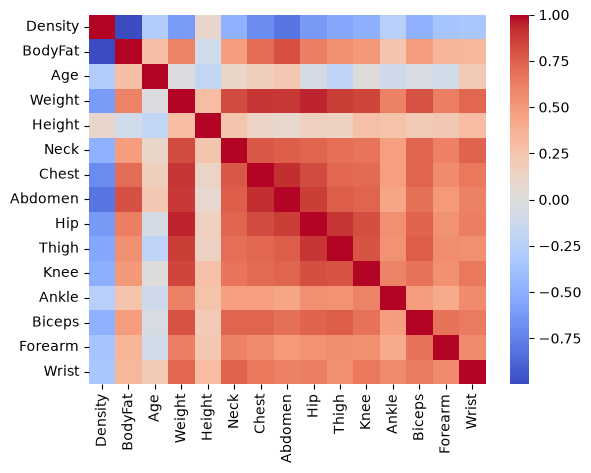

In [9]:
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm')

In [10]:
data['BodyFat'].skew()

np.float64(0.1767283699891579)

<Axes: xlabel='BodyFat', ylabel='Count'>

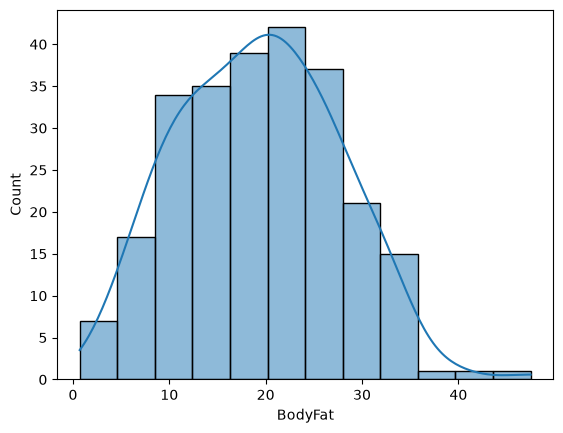

In [11]:
sns.histplot(data['BodyFat'], kde=True)

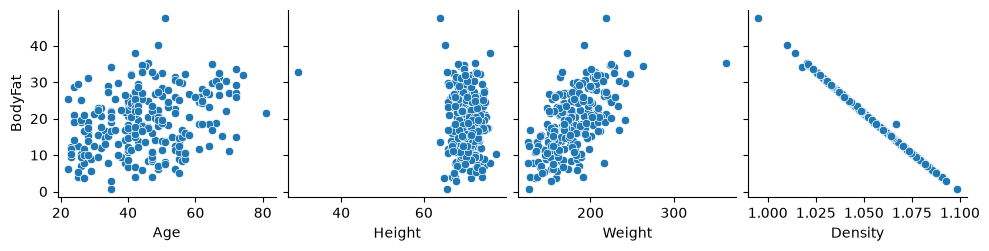

In [12]:
sns.pairplot(data=data, x_vars=['Age', 'Height', 'Weight', 'Density'], y_vars='BodyFat')

In [13]:
data[data['Height'] < 50]

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
41,1.025,32.9,44,205.0,29.5,36.6,106.0,104.3,115.5,70.6,42.5,23.7,33.6,28.7,17.4


In [14]:
data[data['Weight'] > 300]

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
38,1.0202,35.2,46,363.15,72.25,51.2,136.2,148.1,147.7,87.3,49.1,29.6,45.0,29.0,21.4


In [15]:
height_median = data['Height'].median()
data.loc[41, 'Height'] = height_median

In [16]:
data.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,1.055186,19.268540,44.872000,178.983800,70.289000,37.996400,100.860800,92.622000,99.934000,59.445600,38.596000,23.113600,32.289200,28.671600,18.228000
std,0.018599,8.274226,12.638296,29.114459,2.572587,2.418143,8.316654,10.717911,7.114158,5.211749,2.388338,1.691668,3.019203,2.007804,0.920677
min,0.995000,0.700000,22.000000,125.000000,64.000000,31.100000,83.400000,70.400000,85.300000,49.300000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.600000,35.250000,159.250000,68.312500,36.400000,94.450000,84.750000,95.525000,56.025000,37.025000,22.000000,30.225000,27.300000,17.600000
50%,1.054800,19.250000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070050,25.300000,54.000000,196.937500,72.250000,39.400000,105.300000,99.575000,103.425000,62.450000,39.900000,24.000000,34.375000,30.000000,18.800000
max,1.098300,47.500000,81.000000,363.150000,77.500000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


In [17]:
X = data.drop(columns=['BodyFat', 'Density', 'Neck', 'Knee'])
y = data['BodyFat']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [19]:
train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
train_df['BodyFat'] = y_train.values
test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
test_df['BodyFat'] = y_test.values
val_df = pd.DataFrame(X_val_scaled, columns=X_val.columns)
val_df['BodyFat'] = y_val.values

In [20]:
train_dataset = dataset.BodyFatDataset(train_df)
test_dataset = dataset.BodyFatDataset(test_df)
val_dataset = dataset.BodyFatDataset(val_df)

In [21]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [22]:
input_size = X_train.shape[1]
mlp = model.BodyFatMLP(input_size=input_size)
trained_model, history = train.train_model(mlp, train_dataset, val_dataset, epochs=300)

Epoch   1 | train_loss: 433.2385 | val_loss: 427.2387 | val_mae: 19.5252
Epoch   2 | train_loss: 427.3445 | val_loss: 425.1405 | val_mae: 19.4902
Epoch   3 | train_loss: 421.9284 | val_loss: 421.4321 | val_mae: 19.4189
Epoch   4 | train_loss: 417.6240 | val_loss: 416.5648 | val_mae: 19.3269
Epoch   5 | train_loss: 411.7966 | val_loss: 411.0582 | val_mae: 19.2204
Epoch   6 | train_loss: 409.6838 | val_loss: 405.4186 | val_mae: 19.1106
Epoch   7 | train_loss: 404.3527 | val_loss: 399.3866 | val_mae: 18.9837
Epoch   8 | train_loss: 400.2233 | val_loss: 393.3060 | val_mae: 18.8501
Epoch   9 | train_loss: 396.3164 | val_loss: 388.8963 | val_mae: 18.7553
Epoch  10 | train_loss: 391.1953 | val_loss: 384.2606 | val_mae: 18.6504
Epoch  11 | train_loss: 387.6273 | val_loss: 380.8164 | val_mae: 18.5724
Epoch  12 | train_loss: 383.0875 | val_loss: 376.1163 | val_mae: 18.4639
Epoch  13 | train_loss: 376.9262 | val_loss: 372.3637 | val_mae: 18.3746
Epoch  14 | train_loss: 373.5619 | val_loss: 369.08

Text(0, 0.5, 'Loss')

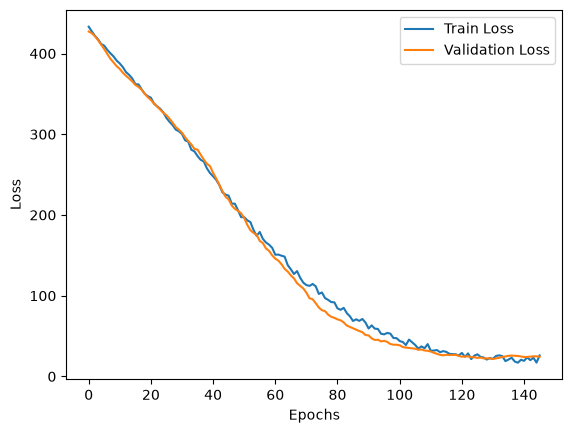

In [23]:
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')

In [24]:
trained_model.eval()

test_metrics, test_preds, test_targets = evaluate.evaluate_model(trained_model, test_loader)
baseline_metrics = evaluate.naive_baseline_metrics(y_train, y_test)

evaluate.print_comparison(test_metrics, baseline_metrics, model_name="MLP Model")

Metric     MLP Model       Baseline       
----------------------------------------
MAE        3.7219          6.4216         
MSE        21.8464         57.2452        
RMSE       4.6740          7.5661         
R2         0.6133          -0.0132        


Test Targets: [ 9.4 19.2 17.8 26.1 21.3 12.1 23.6 23.6 11.7 18.  28.7 24.5 12.4 30.4
 13.8 14.8 22.  20.9 22.5 14.  29.3 16.5 16.7  6.3 29.9 13.9 22.6  7.1
 11.9 25.3  6.  21.3 23.3 26.   3.7 22.1 16.   6.6 11.5  9.4 18.1 11.3
 21.4 20.4 10.9 29.  29.6 12.9 25.3 35.2]
Test Predictions: [ 9.623114  17.270132  12.299492  25.731663  21.629898  16.364681
 15.370261  26.006105   8.6679535 11.503643  23.533747  23.339035
 11.359278  26.768654  12.500091  18.36249   15.311911  27.566645
 18.317219   7.79098   33.131104  21.366901  14.3592825  9.650673
 27.20987    8.239613  22.694149   7.606847  18.711836  22.983585
 15.835004  22.12502   22.919987  26.310204  10.547046  17.785446
 14.41112    9.098309  12.498027  12.6468315 13.135927  12.926783
 24.079464  21.622824  21.633686  22.813667  21.279697  12.88381
 20.918465  45.463024 ]


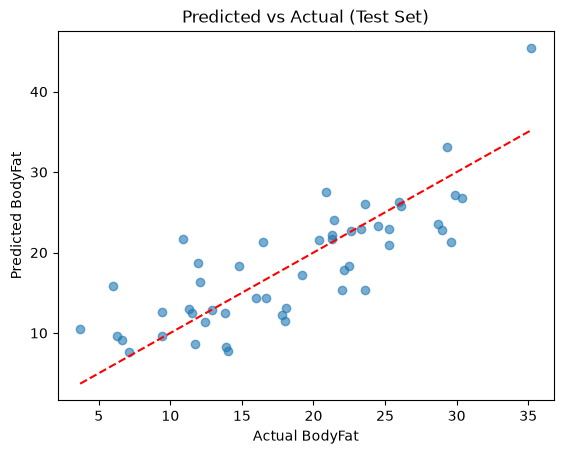

In [29]:
plt.scatter(test_targets, test_preds, alpha=0.6)
plt.plot([test_targets.min(), test_targets.max()], [test_targets.min(), test_targets.max()], 'r--')
plt.xlabel("Actual BodyFat")
plt.ylabel("Predicted BodyFat")
plt.title("Predicted vs Actual (Test Set)")
print(f"Test Targets: {test_targets}")
print(f"Test Predictions: {test_preds}")

In [26]:
torch.save({
    "model_state_dict": trained_model.state_dict(),
    "input_size": X_train.shape[1],
    "hidden_sizes": [64, 32],
    "feature_columns": list(X_train.columns),
}, "../checkpoints/bodyfat_mlp.pt")

joblib.dump(scaler, "../checkpoints/bodyfat_scaler.pkl")

['../checkpoints/bodyfat_scaler.pkl']

Simple Linear Regression Comparaison

In [27]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

lr_mae = np.mean(np.abs(y_test.values - lr_preds))
lr_r2 = lr_model.score(X_test_scaled, y_test)

print(f"Linear Regression Test MAE: {lr_mae:.4f}")
print(f"Linear Regression Test R²:  {lr_r2:.4f}")

Linear Regression Test MAE: 3.5267
Linear Regression Test R²:  0.6582
